# Client-Ready Progress Brief (Partner Edition)

This version is structured as a leave-behind handout your partner can present to potential clients.

In [1]:
from pathlib import Path
from datetime import datetime
import subprocess
try:
    from IPython.display import Markdown, SVG, display
except Exception:
    def Markdown(content):
        return content

    def SVG(content):
        return content

    def display(content):
        print(content)

NOTEBOOK_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "docs" / "client-handoff" / "notebooks",
    Path("docs/client-handoff/notebooks"),
]
NOTEBOOK_DIR = next(
    (
        candidate.resolve()
        for candidate in NOTEBOOK_DIR_CANDIDATES
        if candidate.exists() and (candidate / "../assets").resolve().exists()
    ),
    Path.cwd().resolve(),
)



REPO_ROOT = next(
    (
        candidate.resolve()
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / '.git').exists()
    ),
    Path.cwd().resolve(),
)

def resolve_notebook_path(path):
    target = Path(path)
    if target.is_absolute():
        return target
    return (NOTEBOOK_DIR / target).resolve()


def notebook_markdown_path(path):
    return Path(path).as_posix()


def show_img(path, label='Image'):
    resolved = resolve_notebook_path(path)
    if resolved.exists():
        display(Markdown(f"![{label}]({notebook_markdown_path(path)})"))
    else:
        display(Markdown(f"**Missing {label}**\n\nExpected path: `{path}`"))


def md_table(headers, rows):
    head = '| ' + ' | '.join(headers) + ' |'
    sep = '| ' + ' | '.join(['---'] * len(headers)) + ' |'
    body = ['| ' + ' | '.join(str(c) for c in row) + ' |' for row in rows]
    return '\n'.join([head, sep] + body)


## What Is Already Delivered

- Hospitality CRM base (Guests + Stays)
- Operator-focused dashboard + action board
- Data quality radar and operational readiness KPIs
- Demo data controls and scenario reset flow
- Client handoff docs + presentation notebook system

In [2]:
def count_files(glob_pattern):
    return len(list(REPO_ROOT.glob(glob_pattern)))

counts = [
    ('Client handoff docs', count_files('docs/client-handoff/*.md')),
    ('Presentation notebooks', count_files('docs/client-handoff/notebooks/*.ipynb')),
    ('Results-only presentation markdown files', count_files('docs/client-handoff/notebooks/*.md')),
]
display(Markdown('## Delivery Artifacts Inventory'))
display(Markdown(md_table(['Artifact Type', 'Count'], counts)))

## Delivery Artifacts Inventory

| Artifact Type | Count |
| --- | --- |
| Client handoff docs | 7 |
| Presentation notebooks | 6 |
| Results-only presentation markdown files | 7 |

## Confidence Indicators for Partner + Client

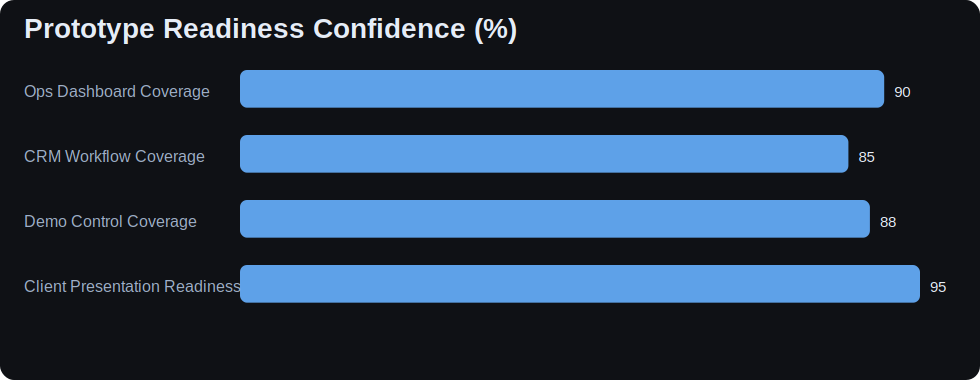

In [3]:
def bar_chart_svg(title, labels, values, width=980, height=380):
    max_v = max(values) if values else 1
    left, top, chart_w, chart_h = 240, 70, width - 300, height - 120
    n = max(len(labels), 1)
    gap = chart_h / n
    bar_h = gap * 0.58
    parts = [f"<text x='24' y='38' fill='#e6edf7' font-size='28' font-family='Arial' font-weight='700'>{title}</text>"]
    for i, (label, value) in enumerate(zip(labels, values)):
        y = top + i * gap
        w = 0 if max_v == 0 else (value / max_v) * chart_w
        parts.append(f"<text x='24' y='{y + bar_h*0.72:.1f}' fill='#9fb0c8' font-size='16' font-family='Arial'>{label}</text>")
        parts.append(f"<rect x='{left}' y='{y:.1f}' width='{w:.1f}' height='{bar_h:.1f}' rx='7' fill='#67b0ff' opacity='0.9'/>")
        parts.append(f"<text x='{left + w + 10:.1f}' y='{y + bar_h*0.72:.1f}' fill='#e6edf7' font-size='15' font-family='Arial'>{value}</text>")
    return f"""<svg xmlns='http://www.w3.org/2000/svg' width='{width}' height='{height}' viewBox='0 0 {width} {height}'>
    <rect x='0' y='0' width='{width}' height='{height}' fill='#0f1115' rx='14'/>
    {' '.join(parts)}
    </svg>"""

labels = [
    'Ops Dashboard Coverage',
    'CRM Workflow Coverage',
    'Demo Control Coverage',
    'Client Presentation Readiness',
]
values = [90, 85, 88, 95]
display(Markdown('## Confidence Indicators for Partner + Client'))
display(SVG(bar_chart_svg('Prototype Readiness Confidence (%)', labels, values)))

## Objection Handling Cheat Sheet

**Objection:** "This is just a website."  
**Answer:** This includes operational queues, quality controls, and readiness KPIs inside admin workflows.

**Objection:** "Can this evolve into a real app?"  
**Answer:** Yes - current structure is staged for PWA extraction while keeping WordPress as operations backend where useful.

**Objection:** "How fast can we customize this to our inn?"  
**Answer:** Fast - term mapping + configurable labels + existing docs make renaming and workflow adaptation straightforward.

## Client Meeting Checklist

1. Show landing page brand direction.
2. Show operations overview dashboard and action board.
3. Show one guest record + one stay record edit flow.
4. Show data quality radar + what issues it prevents.
5. Show delivery roadmap and next-phase options.

## Print Instructions

Export this notebook to PDF/HTML for handout. Also share the markdown export on GitHub for clean code-hidden viewing.